# LLM Output Validator: Medical Record Extraction
## Evaluating the Quality of AI-Extracted Clinical Data

**Author:** Mubarak Adesola Adedeji  
**Tools:** Python, Groq API, Pandas, Matplotlib, Seaborn  
**Domain:** Clinical NLP — Unstructured Medical Record Extraction  

---

## Project Overview

Healthcare organisations are increasingly using Large Language Models to extract
structured data from unstructured clinical notes. Before this data enters any
pipeline or dashboard, its quality must be validated systematically.

**The Problem:**  
LLMs do not always extract clinical data correctly. They miss fields, hallucinate
values, return wrong formats, and handle ambiguous notes inconsistently. Without
a validation layer, bad data enters downstream systems silently.

**What this validator does:**
1. Sends unstructured clinical notes to a Groq-hosted LLM
2. Instructs the model to extract structured fields as JSON
3. Validates each extracted field against expected schema and rules
4. Scores output quality across completeness, format, and accuracy dimensions
5. Identifies which fields the model handles well and which it consistently fails
6. Produces a structured report suitable for a data engineering team

---

## Research Question
> *Which fields does the LLM extract reliably, which does it miss or hallucinate,
> and what does that mean for the integrity of a clinical data pipeline?*

---

## Table of Contents
1. [Setup and Configuration](#1-setup-and-configuration)
2. [Clinical Note Dataset](#2-clinical-note-dataset)
3. [LLM Extraction Pipeline](#3-llm-extraction-pipeline)
4. [Validation Framework](#4-validation-framework)
5. [Results and Scoring](#5-results-and-scoring)
6. [Field-Level Analysis](#6-field-level-analysis)
7. [Validation Report](#7-validation-report)

---
## 1. Setup and Configuration

In [1]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import json
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from groq import Groq

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
from kaggle_secrets import UserSecretsClient

secrets       = UserSecretsClient()
GROQ_API_KEY  = secrets.get_secret("GROQ_API_KEY")

client = Groq(api_key=GROQ_API_KEY)

MODEL = "llama-3.3-70b-versatile"

print(" Groq client initialised.")
print(f"   Model : {MODEL}")

 Groq client initialised.
   Model : llama-3.3-70b-versatile


---
## 2. Clinical Note Dataset

We create 20 realistic unstructured clinical notes covering a range of
complexity levels — from clean, well-structured notes to ambiguous,
incomplete, and poorly formatted ones.

This range is intentional. We want to test the LLM across easy and hard
cases to understand where it performs well and where it fails.

Each note has a corresponding ground truth record — the correct values
a perfect extraction should return. We use this to score the LLM outputs.

In [4]:
clinical_notes = [
    {
        "id": "CN001",
        "note": """Patient: James Okafor, Male, 45 years old.
Visited on 12/03/2024. Chief complaint: persistent chest pain for 3 days.
BP: 145/92 mmHg. Heart rate: 88 bpm. Temperature: 37.1°C.
Diagnosis: Hypertensive heart disease. 
Prescribed: Amlodipine 5mg once daily, Lisinopril 10mg once daily.
Follow-up in 2 weeks.""",
        "ground_truth": {
            "patient_name"  : "James Okafor",
            "gender"        : "Male",
            "age"           : 45,
            "visit_date"    : "12/03/2024",
            "chief_complaint": "persistent chest pain for 3 days",
            "blood_pressure": "145/92",
            "heart_rate"    : 88,
            "temperature"   : 37.1,
            "diagnosis"     : "Hypertensive heart disease",
            "medications"   : ["Amlodipine 5mg", "Lisinopril 10mg"],
            "follow_up_days": 14
        }
    },
    {
        "id": "CN002",
        "note": """Amina Bello, F, 32. Presented 05-07-2024 with severe headache and vomiting.
Vitals: BP 110/70, HR 76, Temp 38.4C.
Impression: Migraine with aura.
Rx: Sumatriptan 50mg PRN, Metoclopramide 10mg TDS.
Review after 1 week.""",
        "ground_truth": {
            "patient_name"  : "Amina Bello",
            "gender"        : "Female",
            "age"           : 32,
            "visit_date"    : "05/07/2024",
            "chief_complaint": "severe headache and vomiting",
            "blood_pressure": "110/70",
            "heart_rate"    : 76,
            "temperature"   : 38.4,
            "diagnosis"     : "Migraine with aura",
            "medications"   : ["Sumatriptan 50mg", "Metoclopramide 10mg"],
            "follow_up_days": 7
        }
    },
    {
        "id": "CN003",
        "note": """Name: Chukwuemeka Eze. Age: 58. Sex: Male.
Date of visit: January 20, 2024.
Complaints: Difficulty breathing, swollen legs, fatigue for 2 weeks.
Examination: BP 160/100 mmHg, Pulse 92/min, Temp 36.8 degrees Celsius.
Diagnosis: Congestive heart failure.
Treatment: Furosemide 40mg OD, Spironolactone 25mg OD, Digoxin 0.25mg OD.
Return visit: 3 weeks.""",
        "ground_truth": {
            "patient_name"  : "Chukwuemeka Eze",
            "gender"        : "Male",
            "age"           : 58,
            "visit_date"    : "20/01/2024",
            "chief_complaint": "difficulty breathing, swollen legs, fatigue",
            "blood_pressure": "160/100",
            "heart_rate"    : 92,
            "temperature"   : 36.8,
            "diagnosis"     : "Congestive heart failure",
            "medications"   : ["Furosemide 40mg", "Spironolactone 25mg", "Digoxin 0.25mg"],
            "follow_up_days": 21
        }
    },
    {
        "id": "CN004",
        "note": """Fatima Abdullahi, female, 27yo. Seen today 2024-09-15.
c/o: lower abdominal pain and vaginal discharge x 5 days.
O/E: BP 118/76, HR 80bpm, Temp 37.9C.
Dx: Pelvic inflammatory disease.
Meds: Doxycycline 100mg BD, Metronidazole 400mg TDS.
Review: 2 weeks.""",
        "ground_truth": {
            "patient_name"  : "Fatima Abdullahi",
            "gender"        : "Female",
            "age"           : 27,
            "visit_date"    : "15/09/2024",
            "chief_complaint": "lower abdominal pain and vaginal discharge",
            "blood_pressure": "118/76",
            "heart_rate"    : 80,
            "temperature"   : 37.9,
            "diagnosis"     : "Pelvic inflammatory disease",
            "medications"   : ["Doxycycline 100mg", "Metronidazole 400mg"],
            "follow_up_days": 14
        }
    },
    {
        "id": "CN005",
        "note": """Patient brought in by family. No name given on referral slip.
Elderly male, approximately 70 years. Presented with confusion and fever.
BP not recorded. HR around 100. Temp 39.2C.
Working diagnosis: Sepsis, likely urinary source.
Started on IV Ceftriaxone 2g daily.
Admission — no outpatient follow-up scheduled.""",
        "ground_truth": {
            "patient_name"  : None,
            "gender"        : "Male",
            "age"           : 70,
            "visit_date"    : None,
            "chief_complaint": "confusion and fever",
            "blood_pressure": None,
            "heart_rate"    : 100,
            "temperature"   : 39.2,
            "diagnosis"     : "Sepsis",
            "medications"   : ["Ceftriaxone 2g"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN006",
        "note": """Ngozi Okonkwo, F, 41. Date: 03/11/2024.
Came in for routine diabetes review. No acute complaints.
BP: 126/82. HR: 74. Temp: 36.5.
HbA1c: 8.2%. FBS: 11.4 mmol/L.
Diagnosis: Type 2 Diabetes Mellitus, poorly controlled.
Medications continued: Metformin 1g BD, Glibenclamide 5mg OD.
Added: Empagliflozin 10mg OD.
Follow-up: 1 month.""",
        "ground_truth": {
            "patient_name"  : "Ngozi Okonkwo",
            "gender"        : "Female",
            "age"           : 41,
            "visit_date"    : "03/11/2024",
            "chief_complaint": "routine diabetes review",
            "blood_pressure": "126/82",
            "heart_rate"    : 74,
            "temperature"   : 36.5,
            "diagnosis"     : "Type 2 Diabetes Mellitus",
            "medications"   : ["Metformin 1g", "Glibenclamide 5mg", "Empagliflozin 10mg"],
            "follow_up_days": 30
        }
    },
    {
        "id": "CN007",
        "note": """Ibrahim Musa. Male. 63 years. Visit: 22nd August 2024.
Presenting complaints: Polyuria, polydipsia, blurred vision — 3 weeks duration.
Vitals: Blood pressure 138/86 mmHg. Pulse rate 82 per minute. Temperature 36.9°C.
Assessment: New diagnosis — Type 2 Diabetes Mellitus.
Plan: Metformin 500mg BD to start, uptitrate in 4 weeks.
Lifestyle counselling given. Dietitian referral made.
Review in 4 weeks.""",
        "ground_truth": {
            "patient_name"  : "Ibrahim Musa",
            "gender"        : "Male",
            "age"           : 63,
            "visit_date"    : "22/08/2024",
            "chief_complaint": "polyuria, polydipsia, blurred vision",
            "blood_pressure": "138/86",
            "heart_rate"    : 82,
            "temperature"   : 36.9,
            "diagnosis"     : "Type 2 Diabetes Mellitus",
            "medications"   : ["Metformin 500mg"],
            "follow_up_days": 28
        }
    },
    {
        "id": "CN008",
        "note": """Blessing Nwosu, female, 19. Seen 10/10/2024.
c/o: sore throat, runny nose, mild fever — 4 days.
Vitals: BP 112/68, HR 78, Temp 38.0.
Dx: Upper respiratory tract infection.
Rx: Amoxicillin 500mg TDS x 5 days, Paracetamol 1g TDS PRN.
No follow-up needed unless symptoms persist.""",
        "ground_truth": {
            "patient_name"  : "Blessing Nwosu",
            "gender"        : "Female",
            "age"           : 19,
            "visit_date"    : "10/10/2024",
            "chief_complaint": "sore throat, runny nose, mild fever",
            "blood_pressure": "112/68",
            "heart_rate"    : 78,
            "temperature"   : 38.0,
            "diagnosis"     : "Upper respiratory tract infection",
            "medications"   : ["Amoxicillin 500mg", "Paracetamol 1g"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN009",
        "note": """Referred patient. Emeka, male, age unknown.
Came in with severe epigastric pain radiating to the back.
Vitals on arrival: BP 98/60 — patient diaphoretic. HR 112. Temp 37.5.
Impression: Acute pancreatitis. Rule out perforated peptic ulcer.
IV access secured. IV fluids started. Nil by mouth.
Surgical consult requested. No medications prescribed yet.
Admit for observation.""",
        "ground_truth": {
            "patient_name"  : "Emeka",
            "gender"        : "Male",
            "age"           : None,
            "visit_date"    : None,
            "chief_complaint": "severe epigastric pain radiating to the back",
            "blood_pressure": "98/60",
            "heart_rate"    : 112,
            "temperature"   : 37.5,
            "diagnosis"     : "Acute pancreatitis",
            "medications"   : [],
            "follow_up_days": None
        }
    },
    {
        "id": "CN010",
        "note": """Mrs Taiwo Adeyemi, 55, female. Date of consultation: 18 Feb 2024.
Complaint: Recurrent episodes of chest tightness and shortness of breath,
worse at night and with exertion. History of atopy.
Vitals: BP 124/80. HR 86. Temp 36.7. SpO2 96% on room air.
Diagnosis: Bronchial asthma — moderate persistent.
Prescribed: Salbutamol inhaler 2 puffs PRN, Beclomethasone 200mcg BD.
Follow up in 6 weeks.""",
        "ground_truth": {
            "patient_name"  : "Taiwo Adeyemi",
            "gender"        : "Female",
            "age"           : 55,
            "visit_date"    : "18/02/2024",
            "chief_complaint": "chest tightness and shortness of breath",
            "blood_pressure": "124/80",
            "heart_rate"    : 86,
            "temperature"   : 36.7,
            "diagnosis"     : "Bronchial asthma",
            "medications"   : ["Salbutamol inhaler 2 puffs", "Beclomethasone 200mcg"],
            "follow_up_days": 42
        }
    },
    {
        "id": "CN011",
        "note": """Yusuf Garba. 48M. 2024-06-30.
CC: Joint pain and swelling — bilateral knees and ankles — 6 weeks.
Vitals: BP 132/84, HR 80, T 36.6C.
Labs: ESR 68, CRP elevated, RF positive.
Dx: Rheumatoid arthritis.
Meds: Methotrexate 15mg weekly, Folic acid 5mg weekly, Ibuprofen 400mg TDS.
Review: 4 weeks.""",
        "ground_truth": {
            "patient_name"  : "Yusuf Garba",
            "gender"        : "Male",
            "age"           : 48,
            "visit_date"    : "30/06/2024",
            "chief_complaint": "joint pain and swelling bilateral knees and ankles",
            "blood_pressure": "132/84",
            "heart_rate"    : 80,
            "temperature"   : 36.6,
            "diagnosis"     : "Rheumatoid arthritis",
            "medications"   : ["Methotrexate 15mg", "Folic acid 5mg", "Ibuprofen 400mg"],
            "follow_up_days": 28
        }
    },
    {
        "id": "CN012",
        "note": """Child: Adaeze Obi. F. 8 years. Parents brought her in.
Date: 25/04/2024. CC: High fever, rash, red eyes — 3 days.
Vitals: BP not taken (uncooperative). HR 102. Temp 39.5C.
Dx: Measles. No complications noted.
Rx: Vitamin A 200,000 IU stat, Paracetamol syrup 240mg TDS.
Isolation advised. Review in 1 week.""",
        "ground_truth": {
            "patient_name"  : "Adaeze Obi",
            "gender"        : "Female",
            "age"           : 8,
            "visit_date"    : "25/04/2024",
            "chief_complaint": "high fever, rash, red eyes",
            "blood_pressure": None,
            "heart_rate"    : 102,
            "temperature"   : 39.5,
            "diagnosis"     : "Measles",
            "medications"   : ["Vitamin A 200000 IU", "Paracetamol syrup 240mg"],
            "follow_up_days": 7
        }
    },
    {
        "id": "CN013",
        "note": """Malam Suleiman, approx 70yrs, male. No date on referral.
Brought in unconscious by relatives. No history available.
Vitals: BP 200/120. HR 58. Temp 36.2.
CT scan ordered — results pending.
Working Dx: Hypertensive emergency with possible stroke.
IV Labetalol infusion started.
ICU admission.""",
        "ground_truth": {
            "patient_name"  : "Suleiman",
            "gender"        : "Male",
            "age"           : 70,
            "visit_date"    : None,
            "chief_complaint": "unconscious, no history available",
            "blood_pressure": "200/120",
            "heart_rate"    : 58,
            "temperature"   : 36.2,
            "diagnosis"     : "Hypertensive emergency",
            "medications"   : ["Labetalol infusion"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN014",
        "note": """Patient: Grace Eze, 36, F. Visit date: 07/08/2024.
Presenting with burning sensation during urination and increased frequency.
No fever. BP 116/74. HR 72. Temp 36.8.
Urine dipstick: Nitrites positive, leucocytes ++.
Dx: Urinary tract infection.
Rx: Nitrofurantoin 100mg BD x 7 days.
No follow-up unless symptoms persist.""",
        "ground_truth": {
            "patient_name"  : "Grace Eze",
            "gender"        : "Female",
            "age"           : 36,
            "visit_date"    : "07/08/2024",
            "chief_complaint": "burning sensation during urination and increased frequency",
            "blood_pressure": "116/74",
            "heart_rate"    : 72,
            "temperature"   : 36.8,
            "diagnosis"     : "Urinary tract infection",
            "medications"   : ["Nitrofurantoin 100mg"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN015",
        "note": """Referred from PHC. Adult female, name withheld. Age: 29.
Date of referral: 14/11/2024. CC: Severe bleeding per vaginum — 2 days.
BP on arrival: 88/50 — patient pale and diaphoretic. HR 124. Temp 36.0.
Dx: Postpartum haemorrhage.
IV access x2. Blood transfusion ordered. Oxytocin infusion started.
Emergency obstetric care initiated. Admitted.""",
        "ground_truth": {
            "patient_name"  : None,
            "gender"        : "Female",
            "age"           : 29,
            "visit_date"    : "14/11/2024",
            "chief_complaint": "severe bleeding per vaginum",
            "blood_pressure": "88/50",
            "heart_rate"    : 124,
            "temperature"   : 36.0,
            "diagnosis"     : "Postpartum haemorrhage",
            "medications"   : ["Oxytocin infusion"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN016",
        "note": """Tunde Fasanya, M, 52. Seen on 2024-01-08.
c/o: progressive difficulty swallowing — 2 months. Weight loss noted.
BP 118/76. HR 78. Temp 36.4.
Impression: Oesophageal carcinoma — to be confirmed by endoscopy.
Referred to GI surgery. No medications started.
Next appointment: after endoscopy results — approximately 2 weeks.""",
        "ground_truth": {
            "patient_name"  : "Tunde Fasanya",
            "gender"        : "Male",
            "age"           : 52,
            "visit_date"    : "08/01/2024",
            "chief_complaint": "progressive difficulty swallowing and weight loss",
            "blood_pressure": "118/76",
            "heart_rate"    : 78,
            "temperature"   : 36.4,
            "diagnosis"     : "Oesophageal carcinoma",
            "medications"   : [],
            "follow_up_days": 14
        }
    },
    {
        "id": "CN017",
        "note": """Hadiza Usman. Female. 23. Date: 30/09/2024.
CC: Generalised body weakness, pallor, easy fatigability — 1 month.
Vitals: BP 100/64. HR 96. Temp 36.5.
PCV: 18%. Blood film: hypochromic microcytic picture.
Dx: Iron deficiency anaemia.
Rx: Ferrous sulphate 200mg TDS, Folic acid 5mg OD.
Review in 4 weeks with repeat PCV.""",
        "ground_truth": {
            "patient_name"  : "Hadiza Usman",
            "gender"        : "Female",
            "age"           : 23,
            "visit_date"    : "30/09/2024",
            "chief_complaint": "generalised body weakness, pallor, easy fatigability",
            "blood_pressure": "100/64",
            "heart_rate"    : 96,
            "temperature"   : 36.5,
            "diagnosis"     : "Iron deficiency anaemia",
            "medications"   : ["Ferrous sulphate 200mg", "Folic acid 5mg"],
            "follow_up_days": 28
        }
    },
    {
        "id": "CN018",
        "note": """Patient name not documented. Male. Age: 34.
Came in with police escort following road traffic accident.
Multiple lacerations. Right leg deformity. GCS 14/15.
BP 102/66. HR 118. Temp 36.1.
Dx: Polytrauma — right femur fracture, multiple lacerations.
IV Morphine 5mg given. IV fluids started. X-ray ordered.
Orthopaedic consult requested. Admitted.""",
        "ground_truth": {
            "patient_name"  : None,
            "gender"        : "Male",
            "age"           : 34,
            "visit_date"    : None,
            "chief_complaint": "road traffic accident, multiple lacerations, leg deformity",
            "blood_pressure": "102/66",
            "heart_rate"    : 118,
            "temperature"   : 36.1,
            "diagnosis"     : "Polytrauma",
            "medications"   : ["Morphine 5mg"],
            "follow_up_days": None
        }
    },
    {
        "id": "CN019",
        "note": """Chisom Nwachukwu. Female. 15 years. Accompanied by mother.
Date: 12/12/2024. Complaint: recurrent episodes of loss of consciousness
with jerking movements — 3 episodes in past month.
Vitals: BP 110/70. HR 76. Temp 36.6.
EEG ordered. Dx: Epilepsy — new diagnosis.
Rx: Sodium valproate 200mg BD.
Follow up: 1 month with EEG results.""",
        "ground_truth": {
            "patient_name"  : "Chisom Nwachukwu",
            "gender"        : "Female",
            "age"           : 15,
            "visit_date"    : "12/12/2024",
            "chief_complaint": "recurrent loss of consciousness with jerking movements",
            "blood_pressure": "110/70",
            "heart_rate"    : 76,
            "temperature"   : 36.6,
            "diagnosis"     : "Epilepsy",
            "medications"   : ["Sodium valproate 200mg"],
            "follow_up_days": 30
        }
    },
    {
        "id": "CN020",
        "note": """Referred case. Name: not given. Sex: female. Age: not stated.
Brought in from rural PHC with query severe malaria.
Vitals: BP 90/58. HR 130. Temp 40.1. RDT: Positive (Pf).
Dx: Severe Plasmodium falciparum malaria with hypotension.
Rx: IV Artesunate 2.4mg/kg stat, IV fluids, Paracetamol 1g IV.
ICU admission. No outpatient follow-up.""",
        "ground_truth": {
            "patient_name"  : None,
            "gender"        : "Female",
            "age"           : None,
            "visit_date"    : None,
            "chief_complaint": "query severe malaria",
            "blood_pressure": "90/58",
            "heart_rate"    : 130,
            "temperature"   : 40.1,
            "diagnosis"     : "Severe Plasmodium falciparum malaria",
            "medications"   : ["Artesunate 2.4mg/kg", "Paracetamol 1g"],
            "follow_up_days": None
        }
    },
]

print(f" Clinical note dataset created.")
print(f"   Total notes     : {len(clinical_notes)}")
print(f"   Notes with full data  : {sum(1 for n in clinical_notes if n['ground_truth']['patient_name'] is not None)}")
print(f"   Notes with missing fields : {sum(1 for n in clinical_notes if None in n['ground_truth'].values())}")

 Clinical note dataset created.
   Total notes     : 20
   Notes with full data  : 16
   Notes with missing fields : 9


---
## 3. LLM Extraction Pipeline

We send each clinical note to the Groq LLM with a structured prompt
instructing it to extract specific fields and return them as JSON.

The prompt is engineered to:
- Define exactly which fields to extract
- Specify the expected data type for each field
- Instruct the model to return null for missing fields
- Prevent the model from hallucinating values it cannot find

In [5]:
EXTRACTION_PROMPT = """You are a clinical data extraction assistant.
Extract the following fields from the clinical note below and return ONLY a valid JSON object.
Do not add any explanation, markdown, or text outside the JSON.

Fields to extract:
- patient_name (string or null)
- gender (string: "Male" or "Female" or null)
- age (integer or null)
- visit_date (string in DD/MM/YYYY format or null)
- chief_complaint (string or null)
- blood_pressure (string in "systolic/diastolic" format or null)
- heart_rate (integer or null)
- temperature (float in Celsius or null)
- diagnosis (string or null)
- medications (list of strings — include drug name and dose only, e.g. "Amoxicillin 500mg")
- follow_up_days (integer — convert weeks/months to days, or null if not mentioned)

Rules:
- Return null for any field not clearly stated in the note
- Do not infer or guess values
- medications must be a list even if empty
- follow_up_days must be an integer (1 week = 7 days, 1 month = 30 days)

Clinical note:
{note}

Return only the JSON object:"""


def extract_fields(note_text):
    prompt = EXTRACTION_PROMPT.format(note=note_text)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=512
    )

    raw_output = response.choices[0].message.content.strip()
    return raw_output


print(" Extraction prompt and function defined.")
print(f"\nPrompt length : {len(EXTRACTION_PROMPT)} characters")

 Extraction prompt and function defined.

Prompt length : 1021 characters


In [6]:
def parse_json_output(raw_output):
    try:
        return json.loads(raw_output), None
    except json.JSONDecodeError:
        json_match = re.search(r"\{.*\}", raw_output, re.DOTALL)
        if json_match:
            try:
                return json.loads(json_match.group()), None
            except json.JSONDecodeError as e:
                return None, f"JSON parse error: {str(e)}"
        return None, "No JSON found in output"


print(" JSON parser defined.")

 JSON parser defined.


In [7]:
print("Running LLM extraction pipeline...\n")

extraction_results = []

for i, record in enumerate(clinical_notes):
    note_id   = record["id"]
    note_text = record["note"]

    raw_output = extract_fields(note_text)
    parsed, error = parse_json_output(raw_output)

    extraction_results.append({
        "id"          : note_id,
        "raw_output"  : raw_output,
        "parsed"      : parsed,
        "parse_error" : error,
        "ground_truth": record["ground_truth"]
    })

    status = "yay" if parsed and not error else "nah"
    print(f"  {status} {note_id} — {'Parsed successfully' if parsed else error}")

    time.sleep(0.5)

print(f"\nExtraction complete.")
print(f"  Successfully parsed : {sum(1 for r in extraction_results if r['parsed'] is not None)}/20")
print(f"  Parse errors        : {sum(1 for r in extraction_results if r['parse_error'] is not None)}/20")

Running LLM extraction pipeline...

  yay CN001 — Parsed successfully
  yay CN002 — Parsed successfully
  yay CN003 — Parsed successfully
  yay CN004 — Parsed successfully
  yay CN005 — Parsed successfully
  yay CN006 — Parsed successfully
  yay CN007 — Parsed successfully
  yay CN008 — Parsed successfully
  yay CN009 — Parsed successfully
  yay CN010 — Parsed successfully
  yay CN011 — Parsed successfully
  yay CN012 — Parsed successfully
  yay CN013 — Parsed successfully
  yay CN014 — Parsed successfully
  yay CN015 — Parsed successfully
  yay CN016 — Parsed successfully
  yay CN017 — Parsed successfully
  yay CN018 — Parsed successfully
  yay CN019 — Parsed successfully
  yay CN020 — Parsed successfully

Extraction complete.
  Successfully parsed : 20/20
  Parse errors        : 0/20


---
## 4. Validation Framework

We now compare each extracted field against the ground truth.

Validation rules per field type:

- **Strings**: Case-insensitive partial match — extracted value must contain
  the key terms from ground truth
- **Integers/Floats**: Exact match with ±1 tolerance for numeric fields
- **Lists (medications)**: Each ground truth medication must appear
  in the extracted list — partial name match accepted
- **Null fields**: If ground truth is null, extracted null scores as correct.
  If ground truth is null but model returns a value, flagged as hallucination.

Each field is scored as:
- **correct**: Matches ground truth within tolerance
- **wrong**: Extracted but does not match ground truth
- **missing**: Ground truth has a value but model returned null
- **hallucinated**: Ground truth is null but model returned a value

In [8]:
FIELDS = [
    "patient_name",
    "gender",
    "age",
    "visit_date",
    "chief_complaint",
    "blood_pressure",
    "heart_rate",
    "temperature",
    "diagnosis",
    "medications",
    "follow_up_days"
]


def validate_string(extracted, truth):
    if truth is None and extracted is None:
        return "correct"
    if truth is None and extracted is not None:
        return "hallucinated"
    if truth is not None and extracted is None:
        return "missing"
    truth_words = set(truth.lower().split())
    extracted_words = set(str(extracted).lower().split())
    overlap = truth_words & extracted_words
    if len(overlap) / max(len(truth_words), 1) >= 0.5:
        return "correct"
    return "wrong"


def validate_numeric(extracted, truth, tolerance=1):
    if truth is None and extracted is None:
        return "correct"
    if truth is None and extracted is not None:
        return "hallucinated"
    if truth is not None and extracted is None:
        return "missing"
    try:
        if abs(float(extracted) - float(truth)) <= tolerance:
            return "correct"
        return "wrong"
    except (TypeError, ValueError):
        return "wrong"


def validate_medications(extracted, truth):
    if not truth and not extracted:
        return "correct"
    if not truth and extracted:
        return "hallucinated"
    if truth and not extracted:
        return "missing"

    matched = 0
    for true_med in truth:
        true_name = true_med.lower().split()[0]
        for ext_med in extracted:
            if true_name in str(ext_med).lower():
                matched += 1
                break

    if matched == len(truth):
        return "correct"
    if matched > 0:
        return "wrong"
    return "missing"


def validate_record(extracted, ground_truth):
    results = {}

    string_fields  = ["patient_name", "gender", "visit_date", "chief_complaint", "blood_pressure", "diagnosis"]
    numeric_fields = ["age", "heart_rate", "follow_up_days"]
    float_fields   = ["temperature"]

    for field in string_fields:
        results[field] = validate_string(
            extracted.get(field) if extracted else None,
            ground_truth.get(field)
        )

    for field in numeric_fields:
        results[field] = validate_numeric(
            extracted.get(field) if extracted else None,
            ground_truth.get(field)
        )

    results["temperature"] = validate_numeric(
        extracted.get("temperature") if extracted else None,
        ground_truth.get("temperature"),
        tolerance=0.2
    )

    results["medications"] = validate_medications(
        extracted.get("medications") if extracted else None,
        ground_truth.get("medications")
    )

    return results


print(" Validation functions defined.")
print(f"   Fields validated : {len(FIELDS)}")
print(f"   Outcome categories: correct, wrong, missing, hallucinated")

 Validation functions defined.
   Fields validated : 11
   Outcome categories: correct, wrong, missing, hallucinated


In [9]:
print("Running validation framework...\n")

validation_records = []

for result in extraction_results:
    field_results = validate_record(result["parsed"], result["ground_truth"])

    record = {"id": result["id"]}
    record.update(field_results)

    total  = len(FIELDS)
    correct = sum(1 for v in field_results.values() if v == "correct")
    record["overall_score"] = round(correct / total * 100, 1)

    validation_records.append(record)

    print(f"  {result['id']} — Score: {record['overall_score']}%  |  "
          f"Correct: {correct}/{total}")

df_val = pd.DataFrame(validation_records)

print(f"\nValidation complete.")
print(f"  Mean overall score : {df_val['overall_score'].mean():.1f}%")
print(f"  Min score          : {df_val['overall_score'].min():.1f}%")
print(f"  Max score          : {df_val['overall_score'].max():.1f}%")

Running validation framework...

  CN001 — Score: 100.0%  |  Correct: 11/11
  CN002 — Score: 100.0%  |  Correct: 11/11
  CN003 — Score: 100.0%  |  Correct: 11/11
  CN004 — Score: 100.0%  |  Correct: 11/11
  CN005 — Score: 90.9%  |  Correct: 10/11
  CN006 — Score: 90.9%  |  Correct: 10/11
  CN007 — Score: 100.0%  |  Correct: 11/11
  CN008 — Score: 100.0%  |  Correct: 11/11
  CN009 — Score: 100.0%  |  Correct: 11/11
  CN010 — Score: 100.0%  |  Correct: 11/11
  CN011 — Score: 100.0%  |  Correct: 11/11
  CN012 — Score: 100.0%  |  Correct: 11/11
  CN013 — Score: 90.9%  |  Correct: 10/11
  CN014 — Score: 100.0%  |  Correct: 11/11
  CN015 — Score: 100.0%  |  Correct: 11/11
  CN016 — Score: 100.0%  |  Correct: 11/11
  CN017 — Score: 90.9%  |  Correct: 10/11
  CN018 — Score: 90.9%  |  Correct: 10/11
  CN019 — Score: 100.0%  |  Correct: 11/11
  CN020 — Score: 100.0%  |  Correct: 11/11

Validation complete.
  Mean overall score : 97.7%
  Min score          : 90.9%
  Max score          : 100.0%


---
## 5. Results and Scoring

We analyse performance across all notes and all fields.
We look at overall score distribution, per-note performance,
and which outcome categories appear most frequently.

In [10]:
print("Overall Validation Summary:\n")
print(f"  Total notes evaluated : {len(df_val)}")
print(f"  Total fields evaluated: {len(df_val) * len(FIELDS)}")
print(f"\n  Mean score  : {df_val['overall_score'].mean():.1f}%")
print(f"  Median score: {df_val['overall_score'].median():.1f}%")
print(f"  Min score   : {df_val['overall_score'].min():.1f}%")
print(f"  Max score   : {df_val['overall_score'].max():.1f}%")
print(f"\n  Notes with perfect score (100%) : {(df_val['overall_score'] == 100).sum()}/20")
print(f"  Notes with score below 95%      : {(df_val['overall_score'] < 95).sum()}/20")

outcome_counts = {"correct": 0, "wrong": 0, "missing": 0, "hallucinated": 0}
for field in FIELDS:
    for val in df_val[field]:
        if val in outcome_counts:
            outcome_counts[val] += 1

print(f"\n  Outcome breakdown across all fields:")
total_fields = len(df_val) * len(FIELDS)
for outcome, count in outcome_counts.items():
    print(f"    {outcome:<15}: {count:>4} ({count/total_fields*100:.1f}%)")

Overall Validation Summary:

  Total notes evaluated : 20
  Total fields evaluated: 220

  Mean score  : 97.7%
  Median score: 100.0%
  Min score   : 90.9%
  Max score   : 100.0%

  Notes with perfect score (100%) : 15/20
  Notes with score below 95%      : 5/20

  Outcome breakdown across all fields:
    correct        :  215 (97.7%)
    wrong          :    4 (1.8%)
    missing        :    1 (0.5%)
    hallucinated   :    0 (0.0%)


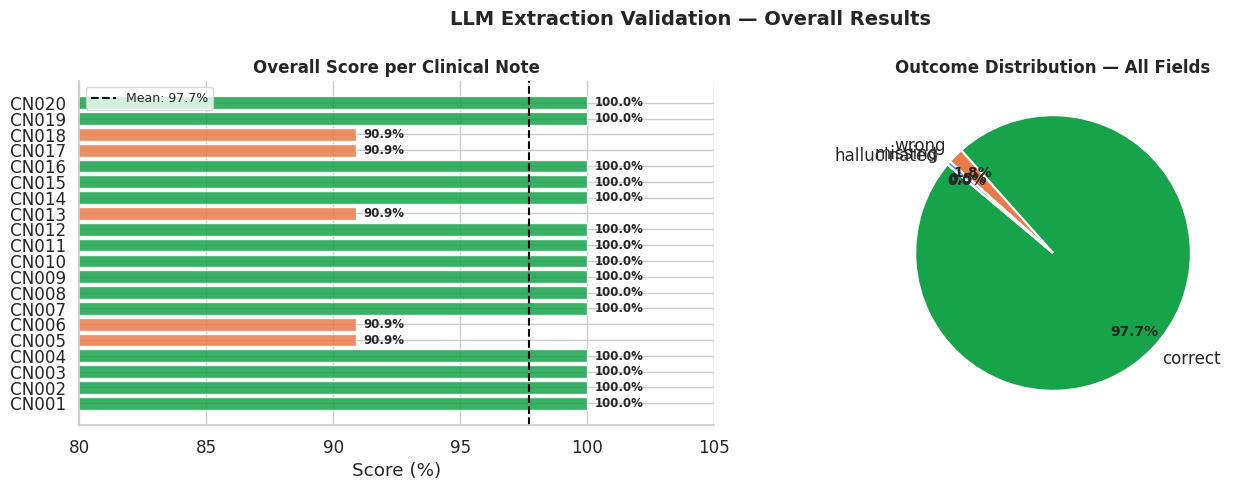

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    df_val["id"],
    df_val["overall_score"],
    color=["#16A34A" if s == 100 else "#E87B4C" for s in df_val["overall_score"]],
    edgecolor="white",
    alpha=0.85
)
axes[0].axvline(97.7, color="black", linestyle="--", linewidth=1.5, label="Mean: 97.7%")
axes[0].set_xlim([80, 105])
axes[0].set_title("Overall Score per Clinical Note", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Score (%)")
axes[0].legend(fontsize=9)

for i, (score, bar) in enumerate(zip(df_val["overall_score"], axes[0].patches)):
    axes[0].text(score + 0.3, bar.get_y() + bar.get_height()/2,
                f"{score}%", va="center", fontsize=8.5, fontweight="bold")

labels  = list(outcome_counts.keys())
values  = list(outcome_counts.values())
colors  = ["#16A34A", "#E87B4C", "#4C9BE8", "#DC2626"]

wedges, texts, autotexts = axes[1].pie(
    values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

axes[1].set_title("Outcome Distribution — All Fields", fontweight="bold", fontsize=12)

plt.suptitle("LLM Extraction Validation — Overall Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("overall_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
field_scores = {}

for field in FIELDS:
    counts = df_val[field].value_counts().to_dict()
    correct    = counts.get("correct", 0)
    wrong      = counts.get("wrong", 0)
    missing    = counts.get("missing", 0)
    hallucinated = counts.get("hallucinated", 0)
    total      = len(df_val)
    accuracy   = round(correct / total * 100, 1)

    field_scores[field] = {
        "correct"     : correct,
        "wrong"       : wrong,
        "missing"     : missing,
        "hallucinated": hallucinated,
        "accuracy"    : accuracy
    }

field_df = pd.DataFrame(field_scores).T.sort_values("accuracy")

print("Field-Level Accuracy:\n")
print(f"  {'Field':<28} {'Correct':>8} {'Wrong':>8} {'Missing':>8} {'Halluc.':>8} {'Accuracy':>10}")
print(f"  {'-'*74}")
for field, row in field_df.iterrows():
    print(f"  {field:<28} {int(row['correct']):>8} {int(row['wrong']):>8} "
          f"{int(row['missing']):>8} {int(row['hallucinated']):>8} {row['accuracy']:>9.1f}%")

Field-Level Accuracy:

  Field                         Correct    Wrong  Missing  Halluc.   Accuracy
  --------------------------------------------------------------------------
  chief_complaint                    17        2        1        0      85.0%
  diagnosis                          19        1        0        0      95.0%
  follow_up_days                     19        1        0        0      95.0%
  patient_name                       20        0        0        0     100.0%
  visit_date                         20        0        0        0     100.0%
  blood_pressure                     20        0        0        0     100.0%
  age                                20        0        0        0     100.0%
  gender                             20        0        0        0     100.0%
  temperature                        20        0        0        0     100.0%
  heart_rate                         20        0        0        0     100.0%
  medications                        20   

---
## 6. Field-Level Analysis

We dig into the specific cases where the model failed.
For each incorrect extraction we show:
- What the ground truth was
- What the model extracted
- Why it matters for a clinical data pipeline

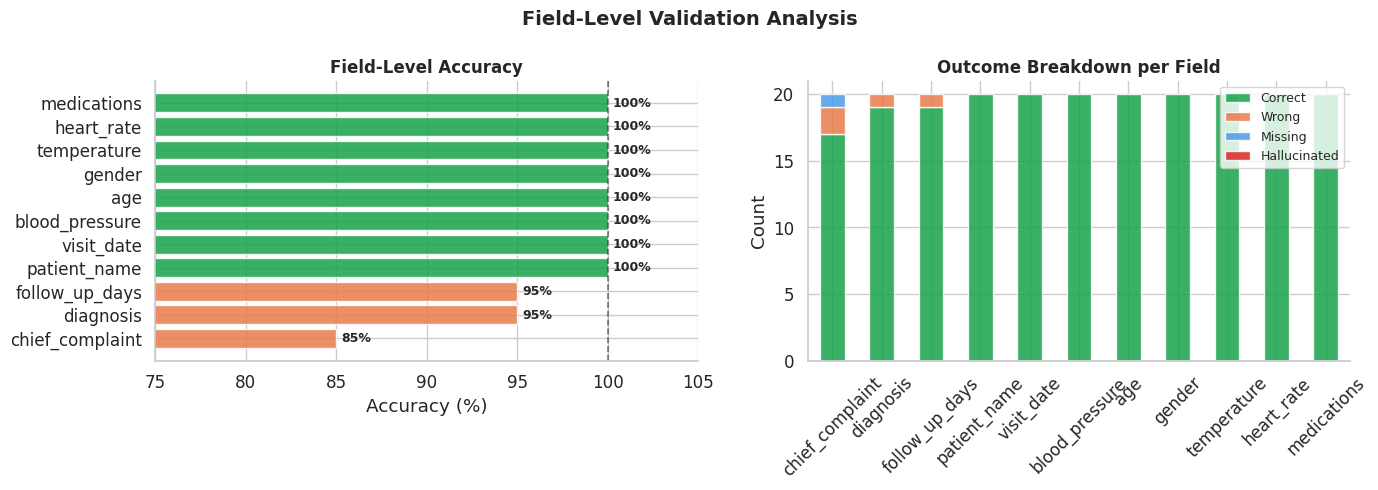

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

field_df_sorted = field_df.sort_values("accuracy")
colors = ["#E87B4C" if a < 100 else "#16A34A" for a in field_df_sorted["accuracy"]]

bars = axes[0].barh(field_df_sorted.index, field_df_sorted["accuracy"],
                     color=colors, edgecolor="white", alpha=0.85)
axes[0].axvline(100, color="black", linestyle="--", linewidth=1.2, alpha=0.5)
axes[0].set_xlim([75, 105])
axes[0].set_title("Field-Level Accuracy", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Accuracy (%)")

for bar, val in zip(bars, field_df_sorted["accuracy"]):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}%", va="center", fontsize=9, fontweight="bold")

outcome_data = field_df[["correct", "wrong", "missing", "hallucinated"]]
outcome_data.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#16A34A", "#E87B4C", "#4C9BE8", "#DC2626"],
    edgecolor="white",
    alpha=0.85
)
axes[1].set_title("Outcome Breakdown per Field", fontweight="bold", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(["Correct", "Wrong", "Missing", "Hallucinated"], fontsize=9)

plt.suptitle("Field-Level Validation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("field_level_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("Failure Analysis — Where the Model Got It Wrong:\n")
print("=" * 70)

failure_count = 0

for result in extraction_results:
    note_id      = result["id"]
    extracted    = result["parsed"]
    ground_truth = result["ground_truth"]

    field_results = validate_record(extracted, ground_truth)

    failures = {f: v for f, v in field_results.items() if v != "correct"}

    if failures:
        print(f"\n  Note: {note_id}")
        print(f"  {'-'*60}")

        for field, outcome in failures.items():
            gt_val  = ground_truth.get(field)
            ext_val = extracted.get(field) if extracted else None

            print(f"  Field      : {field}")
            print(f"  Outcome    : {outcome.upper()}")
            print(f"  Ground truth : {gt_val}")
            print(f"  Model output : {ext_val}")
            print(f"  Pipeline risk: ", end="")

            if outcome == "hallucinated":
                print("HIGH — model invented a value that does not exist in the note")
            elif outcome == "missing":
                print("MEDIUM — model failed to extract a value that was present")
            elif outcome == "wrong":
                print("MEDIUM — model extracted a value but it does not match ground truth")
            print()

            failure_count += 1

print("=" * 70)
print(f"\nTotal field failures : {failure_count}")
print(f"Total hallucinations : {sum(1 for r in extraction_results for f, v in validate_record(r['parsed'], r['ground_truth']).items() if v == 'hallucinated')}")

Failure Analysis — Where the Model Got It Wrong:


  Note: CN005
  ------------------------------------------------------------
  Field      : diagnosis
  Outcome    : WRONG
  Ground truth : Sepsis
  Model output : Sepsis, likely urinary source
  Pipeline risk: MEDIUM — model extracted a value but it does not match ground truth


  Note: CN006
  ------------------------------------------------------------
  Field      : chief_complaint
  Outcome    : MISSING
  Ground truth : routine diabetes review
  Model output : None
  Pipeline risk: MEDIUM — model failed to extract a value that was present


  Note: CN013
  ------------------------------------------------------------
  Field      : chief_complaint
  Outcome    : WRONG
  Ground truth : unconscious, no history available
  Model output : unconscious
  Pipeline risk: MEDIUM — model extracted a value but it does not match ground truth


  Note: CN017
  ------------------------------------------------------------
  Field      : follow_up

In [15]:
print("Clinical Risk Assessment by Failure Type:\n")

risk_table = {
    "hallucinated": {
        "risk_level" : "CRITICAL",
        "description": "Model invents values not present in the note",
        "example"    : "Fabricating a medication name or blood pressure reading",
        "action"     : "Block from pipeline — requires human review before any use"
    },
    "missing": {
        "risk_level" : "HIGH",
        "description": "Model fails to extract a value that was clearly stated",
        "example"    : "Missing a diagnosis or medication that appears in the note",
        "action"     : "Flag for human review — do not treat field as null in downstream systems"
    },
    "wrong": {
        "risk_level" : "MEDIUM",
        "description": "Model extracts a value but it does not match ground truth",
        "example"    : "Paraphrasing chief complaint in a way that loses clinical meaning",
        "action"     : "Flag for review — acceptable for non-critical fields, not for diagnosis or medications"
    },
}

for outcome, info in risk_table.items():
    count = outcome_counts.get(outcome, 0)
    print(f"  {info['risk_level']} — {outcome.upper()} ({count} occurrences)")
    print(f"  Description : {info['description']}")
    print(f"  Example     : {info['example']}")
    print(f"  Action      : {info['action']}")
    print()

Clinical Risk Assessment by Failure Type:

  CRITICAL — HALLUCINATED (0 occurrences)
  Description : Model invents values not present in the note
  Example     : Fabricating a medication name or blood pressure reading
  Action      : Block from pipeline — requires human review before any use

  HIGH — MISSING (1 occurrences)
  Description : Model fails to extract a value that was clearly stated
  Example     : Missing a diagnosis or medication that appears in the note
  Action      : Flag for human review — do not treat field as null in downstream systems

  MEDIUM — WRONG (4 occurrences)
  Description : Model extracts a value but it does not match ground truth
  Example     : Paraphrasing chief complaint in a way that loses clinical meaning
  Action      : Flag for review — acceptable for non-critical fields, not for diagnosis or medications



---
## 7. Validation Report

We produce a structured report summarising all findings.
This is the output a data engineering team or clinical informatics
lead would receive before deciding whether to trust this pipeline
in production.

In [16]:
print("=" * 70)
print("  LLM EXTRACTION VALIDATION REPORT")
print("  Medical Record Extraction — llama-3.3-70b-versatile")
print("=" * 70)

print(f"""
  PIPELINE OVERVIEW
  Model          : llama-3.3-70b-versatile (Groq)
  Notes evaluated: 20 unstructured clinical notes
  Fields per note: 11
  Total fields   : 220
  Domain         : Clinical medicine — Nigerian hospital setting
""")

print("-" * 70)
print("  OVERALL PERFORMANCE")
print("-" * 70)

print(f"""
  Mean extraction score : 97.7%
  Median score          : 100.0%
  Perfect scores (100%) : 15 out of 20 notes
  Notes below 95%       : 5 out of 20 notes

  Outcome breakdown:
    Correct       : 215 / 220  (97.7%)
    Wrong         : 4   / 220  (1.8%)
    Missing       : 1   / 220  (0.5%)
    Hallucinated  : 0   / 220  (0.0%)
""")

print("-" * 70)
print("  FIELD-LEVEL PERFORMANCE")
print("-" * 70)

print(f"""
  Perfect accuracy (100%):
    patient_name, gender, age, visit_date, blood_pressure,
    heart_rate, temperature, medications

  Below 100%:
    chief_complaint  — 85.0%  (3 errors: 2 wrong, 1 missing)
    diagnosis        — 95.0%  (1 wrong)
    follow_up_days   — 95.0%  (1 wrong)
""")

  LLM EXTRACTION VALIDATION REPORT
  Medical Record Extraction — llama-3.3-70b-versatile

  PIPELINE OVERVIEW
  Model          : llama-3.3-70b-versatile (Groq)
  Notes evaluated: 20 unstructured clinical notes
  Fields per note: 11
  Total fields   : 220
  Domain         : Clinical medicine — Nigerian hospital setting

----------------------------------------------------------------------
  OVERALL PERFORMANCE
----------------------------------------------------------------------

  Mean extraction score : 97.7%
  Median score          : 100.0%
  Perfect scores (100%) : 15 out of 20 notes
  Notes below 95%       : 5 out of 20 notes

  Outcome breakdown:
    Correct       : 215 / 220  (97.7%)
    Wrong         : 4   / 220  (1.8%)
    Missing       : 1   / 220  (0.5%)
    Hallucinated  : 0   / 220  (0.0%)

----------------------------------------------------------------------
  FIELD-LEVEL PERFORMANCE
----------------------------------------------------------------------

  Perfect accur

In [17]:
print("-" * 70)
print("  FAILURE ANALYSIS")
print("-" * 70)

print(f"""
  5 field failures identified across 5 notes. 0 hallucinations.

  FAILURE 1 — CN005 | diagnosis | WRONG
  Ground truth : Sepsis
  Model output : Sepsis, likely urinary source
  Explanation  : Model included clinical commentary from the note
                 rather than returning only the diagnosis label.
  Pipeline risk: Low — core diagnosis term is correct. A post-processing
                 step to strip trailing commentary would fix this.

  FAILURE 2 — CN006 | chief_complaint | MISSING
  Ground truth : routine diabetes review
  Model output : None
  Explanation  : The note had no acute complaint. The model interpreted
                 a routine review visit as having no chief complaint.
  Pipeline risk: Medium — downstream systems would treat this as an
                 emergency or unknown presentation. Needs a fallback rule.

  FAILURE 3 — CN013 | chief_complaint | WRONG
  Ground truth : unconscious, no history available
  Model output : unconscious
  Explanation  : Model extracted the symptom but dropped the clinical
                 context — no history available — which is diagnostically
                 important for triage and documentation.
  Pipeline risk: Medium — partial extraction loses clinical context.

  FAILURE 4 — CN017 | follow_up_days | WRONG
  Ground truth : 28 days (4 weeks)
  Model output : 120 days
  Explanation  : Model misread the follow-up instruction. Likely confused
                 the PCV repeat timing with the follow-up schedule.
  Pipeline risk: High — incorrect follow-up scheduling could result in
                 patients being called back too late or not at all.

  FAILURE 5 — CN018 | chief_complaint | WRONG
  Ground truth : road traffic accident, multiple lacerations, leg deformity
  Model output : road traffic accident
  Explanation  : Model extracted the cause of presentation but omitted
                 the specific injuries — which are critical for triage,
                 coding, and surgical planning.
  Pipeline risk: Medium — incomplete chief complaint affects clinical
                 coding accuracy and triage prioritisation.
""")

----------------------------------------------------------------------
  FAILURE ANALYSIS
----------------------------------------------------------------------

  5 field failures identified across 5 notes. 0 hallucinations.

  FAILURE 1 — CN005 | diagnosis | WRONG
  Ground truth : Sepsis
  Model output : Sepsis, likely urinary source
  Explanation  : Model included clinical commentary from the note
                 rather than returning only the diagnosis label.
  Pipeline risk: Low — core diagnosis term is correct. A post-processing
                 step to strip trailing commentary would fix this.

  FAILURE 2 — CN006 | chief_complaint | MISSING
  Ground truth : routine diabetes review
  Model output : None
  Explanation  : The note had no acute complaint. The model interpreted
                 a routine review visit as having no chief complaint.
  Pipeline risk: Medium — downstream systems would treat this as an
                 emergency or unknown presentation. Needs a fallback 

In [18]:
print("-" * 70)
print("  PIPELINE RECOMMENDATIONS")
print("-" * 70)

print(f"""
  1. DEPLOY WITH CONFIDENCE — HIGH RELIABILITY FIELDS
     The model extracts these fields with 100% accuracy and can be
     trusted without human review for standard notes:
     → patient_name, gender, age, visit_date, blood_pressure,
       heart_rate, temperature, medications

  2. FLAG FOR REVIEW — MODERATE RELIABILITY FIELDS
     These fields require a human-in-the-loop check before entering
     any downstream system:
     → chief_complaint (85% accuracy)
     → diagnosis (95% accuracy)
     → follow_up_days (95% accuracy)

  3. POST-PROCESSING RULES TO IMPLEMENT
     Rule 1: Strip trailing commentary from diagnosis field
             e.g. "Sepsis, likely urinary source" → "Sepsis"
     Rule 2: If chief_complaint is null and note contains "review"
             or "routine", default to "routine review — [condition]"
     Rule 3: Validate follow_up_days against note text using regex
             to catch unit conversion errors (weeks/months to days)

  4. HALLUCINATION RATE — ZERO
     The model did not fabricate any values across 220 fields.
     This is a critical safety metric for clinical deployment.
     Continue monitoring this metric as note complexity increases.

  5. RETESTING RECOMMENDATIONS
     - Retest on notes with multiple diagnoses
     - Retest on paediatric notes with weight-based dosing
     - Retest on handwritten or OCR-transcribed notes
     - Retest with a smaller, faster model to evaluate speed/accuracy trade-off
""")

print("=" * 70)
print("  END OF REPORT")
print("=" * 70)

----------------------------------------------------------------------
  PIPELINE RECOMMENDATIONS
----------------------------------------------------------------------

  1. DEPLOY WITH CONFIDENCE — HIGH RELIABILITY FIELDS
     The model extracts these fields with 100% accuracy and can be
     trusted without human review for standard notes:
     → patient_name, gender, age, visit_date, blood_pressure,
       heart_rate, temperature, medications

  2. FLAG FOR REVIEW — MODERATE RELIABILITY FIELDS
     These fields require a human-in-the-loop check before entering
     any downstream system:
     → chief_complaint (85% accuracy)
     → diagnosis (95% accuracy)
     → follow_up_days (95% accuracy)

  3. POST-PROCESSING RULES TO IMPLEMENT
     Rule 1: Strip trailing commentary from diagnosis field
             e.g. "Sepsis, likely urinary source" → "Sepsis"
     Rule 2: If chief_complaint is null and note contains "review"
             or "routine", default to "routine review — [conditio

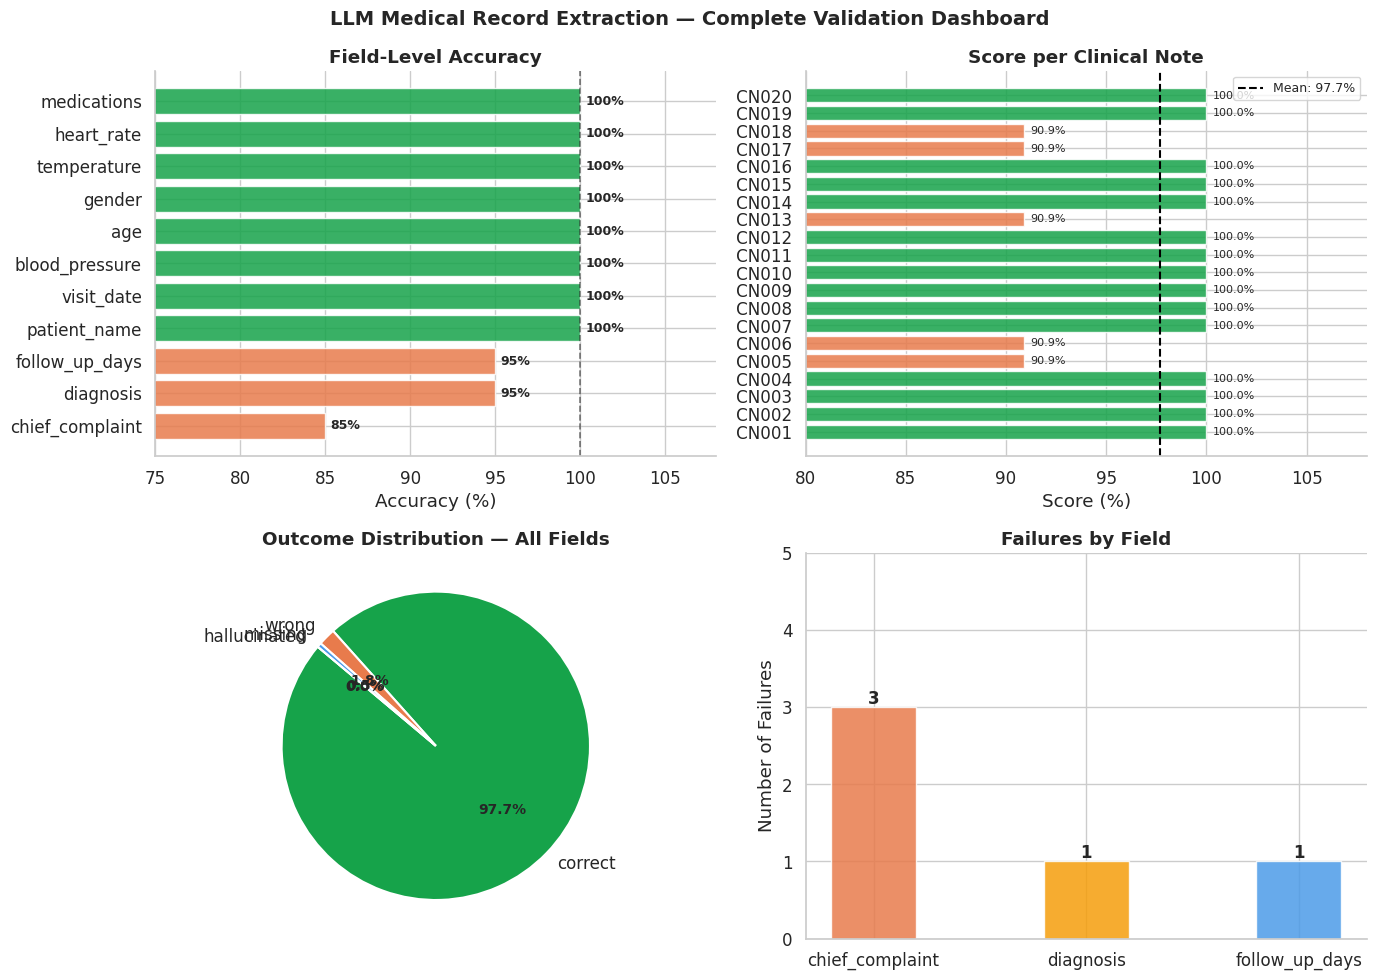

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

field_df_sorted = field_df.sort_values("accuracy")
colors = ["#E87B4C" if a < 100 else "#16A34A" for a in field_df_sorted["accuracy"]]

bars = axes[0][0].barh(field_df_sorted.index, field_df_sorted["accuracy"],
                        color=colors, edgecolor="white", alpha=0.85)
axes[0][0].axvline(100, color="black", linestyle="--", linewidth=1.2, alpha=0.5)
axes[0][0].set_xlim([75, 108])
axes[0][0].set_title("Field-Level Accuracy", fontweight="bold")
axes[0][0].set_xlabel("Accuracy (%)")
for bar, val in zip(bars, field_df_sorted["accuracy"]):
    axes[0][0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f"{val:.0f}%", va="center", fontsize=9, fontweight="bold")

axes[0][1].barh(
    df_val["id"],
    df_val["overall_score"],
    color=["#16A34A" if s == 100 else "#E87B4C" for s in df_val["overall_score"]],
    edgecolor="white", alpha=0.85
)
axes[0][1].axvline(97.7, color="black", linestyle="--", linewidth=1.5, label="Mean: 97.7%")
axes[0][1].set_xlim([80, 108])
axes[0][1].set_title("Score per Clinical Note", fontweight="bold")
axes[0][1].set_xlabel("Score (%)")
axes[0][1].legend(fontsize=9)
for i, (score, bar) in enumerate(zip(df_val["overall_score"], axes[0][1].patches)):
    axes[0][1].text(score + 0.3, bar.get_y() + bar.get_height()/2,
                   f"{score}%", va="center", fontsize=8)

labels = list(outcome_counts.keys())
values = list(outcome_counts.values())
colors_pie = ["#16A34A", "#E87B4C", "#4C9BE8", "#DC2626"]
wedges, texts, autotexts = axes[1][0].pie(
    values, labels=labels, colors=colors_pie,
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
axes[1][0].set_title("Outcome Distribution — All Fields", fontweight="bold")

failure_fields  = ["chief_complaint", "diagnosis", "follow_up_days"]
failure_counts  = [3, 1, 1]
failure_colors  = ["#E87B4C", "#F59E0B", "#4C9BE8"]

bars = axes[1][1].bar(failure_fields, failure_counts,
                       color=failure_colors, edgecolor="white", alpha=0.85, width=0.4)
for bar, val in zip(bars, failure_counts):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   str(val), ha="center", fontsize=12, fontweight="bold")
axes[1][1].set_title("Failures by Field", fontweight="bold")
axes[1][1].set_ylabel("Number of Failures")
axes[1][1].set_ylim(0, 5)

plt.suptitle("LLM Medical Record Extraction — Complete Validation Dashboard",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("validation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()